In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =============================
# LOAD DATASET
# =============================
df = pd.read_csv("final_dual_fluid_shell_tube_dataset.csv")
print("Dataset shape:", df.shape)

Dataset shape: (10000, 19)


In [8]:
# =============================
# CHECK 1 — BASIC SANITY
# =============================
print("\n--- BASIC SANITY CHECK ---")

print("NaN count:\n", df.isna().sum())

assert (df["heat_transfer_rate"] > 0).all(), "Non-positive Q detected"
assert (df["heat_flux"] > 0).all(), "Non-positive heat flux detected"
assert (df["tube_outlet_temp"] > df["shell_outlet_temp"]).all(), "Temperature crossover detected"

print("✔ Sanity checks passed")


--- BASIC SANITY CHECK ---
NaN count:
 tube_fluid                   0
shell_fluid                  0
shell_diameter               0
tube_outer_diameter          0
tube_inner_diameter          0
tube_length                  0
number_of_tubes              0
tube_pitch                   0
baffle_spacing               0
number_of_baffles            0
tube_mass_flow_rate          0
shell_mass_flow_rate         0
tube_inlet_temp              0
tube_outlet_temp             0
shell_inlet_temp             0
shell_outlet_temp            0
tube_thermal_conductivity    0
heat_transfer_rate           0
heat_flux                    0
dtype: int64
✔ Sanity checks passed


/var/folders/h6/pqshhjr94k9111mcsxbb8gmh0000gn/T/ipykernel_3668/2189787505.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  baffle_trend = df.groupby("baffle_bin")["heat_transfer_rate"].mean()


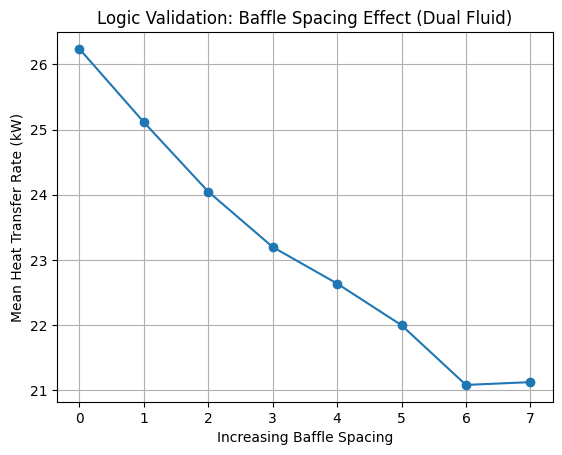

In [9]:
# =============================
# CHECK 2 — BAFFLE SPACING LOGIC
# =============================
df["baffle_bin"] = pd.qcut(df["baffle_spacing"], q=8)

baffle_trend = df.groupby("baffle_bin")["heat_transfer_rate"].mean()

plt.figure()
plt.plot(range(len(baffle_trend)), baffle_trend.values / 1000, marker="o")
plt.xlabel("Increasing Baffle Spacing")
plt.ylabel("Mean Heat Transfer Rate (kW)")
plt.title("Logic Validation: Baffle Spacing Effect (Dual Fluid)")
plt.grid(True)
plt.show()

/var/folders/h6/pqshhjr94k9111mcsxbb8gmh0000gn/T/ipykernel_3668/3731809073.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  flow_trend = df.groupby("tube_flow_bin")["heat_transfer_rate"].mean()


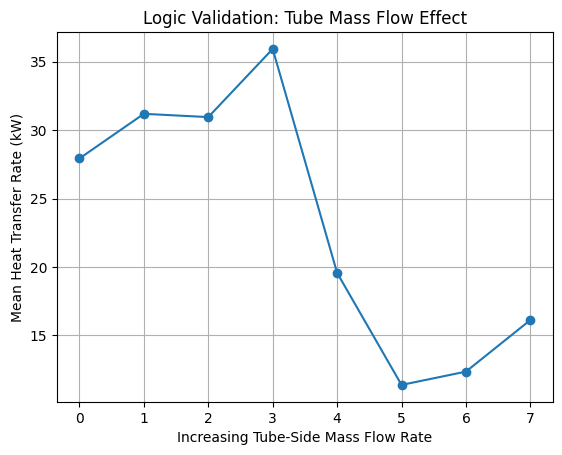

In [10]:
# =============================
# CHECK 3 — TUBE MASS FLOW LOGIC
# =============================
df["tube_flow_bin"] = pd.qcut(df["tube_mass_flow_rate"], q=8)

flow_trend = df.groupby("tube_flow_bin")["heat_transfer_rate"].mean()

plt.figure()
plt.plot(range(len(flow_trend)), flow_trend.values / 1000, marker="o")
plt.xlabel("Increasing Tube-Side Mass Flow Rate")
plt.ylabel("Mean Heat Transfer Rate (kW)")
plt.title("Logic Validation: Tube Mass Flow Effect")
plt.grid(True)
plt.show()

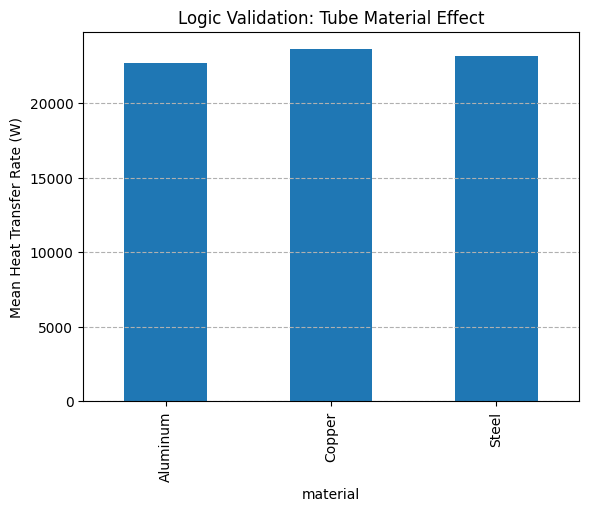


Material-wise mean Q (W):
material
Aluminum    22723.056911
Copper      23615.912003
Steel       23184.172319
Name: heat_transfer_rate, dtype: float64


In [11]:
# =============================
# CHECK 4 — MATERIAL LOGIC
# =============================
def classify_material(k):
    if k < 50:
        return "Steel"
    elif k < 300:
        return "Aluminum"
    else:
        return "Copper"

df["material"] = df["tube_thermal_conductivity"].apply(classify_material)

material_Q = df.groupby("material")["heat_transfer_rate"].mean()

plt.figure()
material_Q.plot(kind="bar")
plt.ylabel("Mean Heat Transfer Rate (W)")
plt.title("Logic Validation: Tube Material Effect")
plt.grid(axis="y", linestyle="--")
plt.show()

print("\nMaterial-wise mean Q (W):")
print(material_Q)

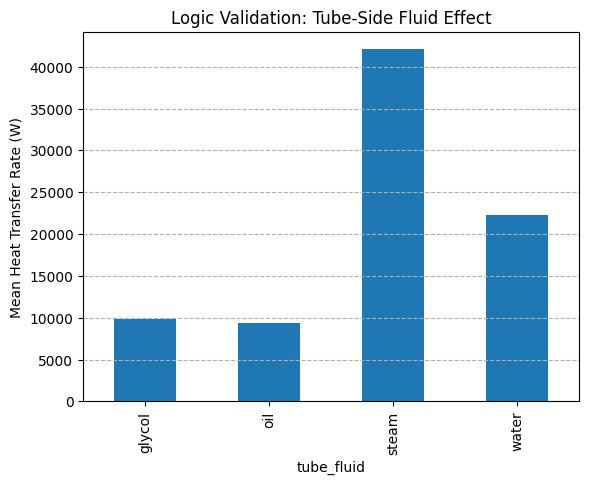


Tube-fluid-wise mean Q (W):
tube_fluid
glycol     9877.554519
oil        9368.080645
steam     42078.405130
water     22323.066106
Name: heat_transfer_rate, dtype: float64


In [12]:
# =============================
# CHECK 5 — FLUID SANITY (TUBE SIDE)
# =============================
tube_fluid_Q = df.groupby("tube_fluid")["heat_transfer_rate"].mean()

plt.figure()
tube_fluid_Q.plot(kind="bar")
plt.ylabel("Mean Heat Transfer Rate (W)")
plt.title("Logic Validation: Tube-Side Fluid Effect")
plt.grid(axis="y", linestyle="--")
plt.show()

print("\nTube-fluid-wise mean Q (W):")
print(tube_fluid_Q)